In [1]:
import matplotlib.pyplot as plt
from SPIXC.data_field import DataField
from SPIXC.swot_processing import SPixc #can be changed to from SPIXC.swot_processing_ast import SPixc for larger files (it's using polars instead of pandas)
import pandas as pd
from pathlib import Path

In [2]:
BASE_DIR = Path.cwd()  # current notebook location
print(BASE_DIR)
DATA_DIR = BASE_DIR.parent / "../data"
print(DATA_DIR)

folder_path = DATA_DIR / "Rosolin_PIXC.csv"
datafield_name = DATA_DIR / "Rosolin_insitu.csv"
polygon_lake = DATA_DIR / "Rosolin_20230807_extent_optic.gpkg"

conditions= {"sig0":{'operator': "gt", 'threshold': 20},
            "cross_track": {'abs_between': [10000,60000]},
             "geolocation_qual": {'operator': "le", 'threshold': 4}} # sig0 > 20

/home/charrierl/Documents/Scripts_dossier/cen_ljk/SPIXC/examples/PIXC_process
/home/charrierl/Documents/Scripts_dossier/cen_ljk/SPIXC/examples/../data


# Load PIXC data and filter them

In [3]:
lakepixc = SPixc(folder_path)
lakepixc.filter_by_variable(conditions)
lakepixc.mask_according_to_polygon(polygon_lake)
lakepixc.filter_by_wsedaystats(method_filter="robust", threshold=2)
lakepixc.filter_by_space_stats(method_filter="normal", threshold=3)
results = lakepixc.compute_weighted_mean_wse_by_day(method_uncertainty="weighted_variance")
wse_by_day,uncertainty = results.wse_by_day, results.uncertainty

# Load insitu data

In [4]:
data_IGE = DataField(datafield_name)

# Plot

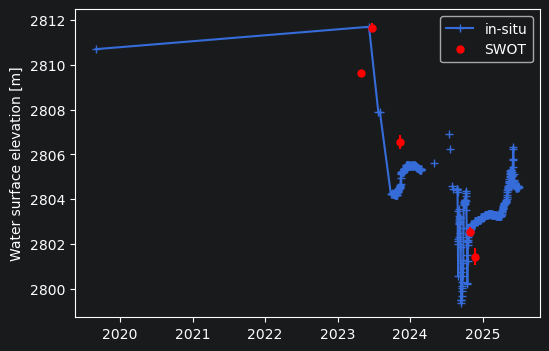

In [5]:
fig,ax = plt.subplots(1,figsize=(6,4))
ax.plot(data_IGE.data["NiveauLac_m"],marker='+',linestyle='-',label='in-situ')
ax.plot(wse_by_day ,marker='o',linestyle='',color='r',label='SWOT',markersize=5)
ax.errorbar(wse_by_day.index,wse_by_day.values,yerr=uncertainty/2,color='r',linestyle='')
ax.set_ylabel('Water surface elevation [m]')
ax.legend()

In [6]:
import plotly.graph_objects as go

# Create base figure
fig = go.Figure()

# --- Second y-axis (WSE SWOT) ---
fig.add_trace(
    go.Scatter(
        x=wse_by_day.index,
        y=wse_by_day,
        mode="markers",
        marker_symbol="x",
        marker_size=9,
        marker_color="orange",
        name="SWOT Water Surface Elevation",
        yaxis="y"
    )
)

# --- Second y-axis (WSE FOEN) ---
fig.add_trace(
    go.Scatter(
        x=data_IGE.data.index,
        y=data_IGE.data["NiveauLac_m"],
        mode="markers",
        marker_symbol="x",
        marker_size=9,
        marker_color="green",
        name="IGE Water Surface Elevation",
        yaxis="y"
    )
)

# --- Layout ---
fig.update_layout(
    title="Rosolin Lake",
    width=900,
    height=500,

    # Axes
    xaxis=dict(
        title="Observation date",
        range=[pd.Timestamp("2023-01-01"), pd.Timestamp("2025-11-30")]
    ),
    yaxis=dict(
        title="WSE (m)",
        overlaying="y",
        side="right",
    ),

    # Legend centered at bottom
    legend=dict(
        orientation="h",
        y=-0.25,
        x=0.5,
        xanchor="center",
        yanchor="top",
        font=dict(size=13)
    ),
    margin=dict(b=100)
)

# Save figure
fig.show()


# Compute some statitics

In [7]:
stats_tabi,aligned = data_IGE.stats(wse_by_day,preprocessing="sig0sup20_one_polygon",method_interp="linear")
stats_tabi

,preprocessing,RMSE,Bias,KGE,MAE,MAPE,R2,R,nb_points
0,sig0sup20_one_polygon,1.53926,-0.124072,0.918484,1.371887,0.000489,0.8398,0.92277,5
